## __Aprendizaje no supervisado__

__Profesor__: Anthony D. Cho

__Ayudante__: Luis Oliveros

__Asunto__: Detección de anomalias

__Evaluación__: Actividad 03

***

**Estudiantes**: (Recordar colocar los RUTs, nombres y apellidos)

* 
*
*

#### Instrucciones
* La actividad puede ser realizada en grupo de hasta 3 personas.
* Por favor responder en este mismo notebook.
* Renombrar el archivo agregando el apellido de las y los integrantes, por ejemplo Actividad_03_Akina_Nosta.ipynb
* Una vez completada la tarea, uno de los integrantes debe subir al enlace habilitada en el Webcursos.

+ __Fecha de entrega:__ viernes 24 de octubre de 2025, 23:59 hrs chile.

#### Objetivo de la actividad

Aplicar las técnicas aprendidas de detección de anomalias en datos suministrados.

## Librerias

In [19]:
!pip install scikit-learn



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
!pip install numpy pandas matplotlib seaborn scikit-learn kneed
!pip install missingno


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import numpy as np
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from platform import system
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator
from sklearn.model_selection import train_test_split

In [22]:
from platform import system
from pandas import read_csv, set_option, DataFrame
set_option("display.max_columns", None)

## Agregar las librerias que van a usar


## Dataset:

El conjunto de datos contiene transacciones realizadas con tarjetas de crédito en septiembre de 2013 por titulares de tarjetas europeos. Este conjunto de datos contiene 284.807 transacciones que ocurrieron en dos días.

* La data está completamente disponible en el [Kaggle - Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) que se puede descargar gratuitamente.

<center>
    <img src='https://media.licdn.com/dms/image/v2/D4D12AQFlmAfjgld0xA/article-cover_image-shrink_600_2000/article-cover_image-shrink_600_2000/0/1694776207408?e=2147483647&v=beta&t=hndgTnmw8DaUXFd6CNPVnMhVTG6iU5K_EFmLKBrVUIg' width=800>
<center>

<p style="color:red"> <b>Instrucciones para usuarios que usan Windows y MacOS: </b></p>

* Descargar la data pulsando [¡¡AQUI!!](https://github.com/adoc-box/Datasets/raw/refs/heads/main/creditcard.zip)
* Descomprimir el archivo creditcard.zip en la misma carpeta donde se encuentra el script, teniendo sólo el archivo con el nombre "__creditcard.csv__" y el script juntos.
* Ya con eso, debería poder ejecutar el script sin ningun problema.

## Carga de datos

In [23]:
df = pd.read_csv("creditcard.csv")

## Paso 1: Pre-procesamiento de los features

En este paso, apliquen las operaciones de transformaciones que consideren ser necesarios en las particiones de los datos previos.

__NOTA__: recuerde que ciertos algoritmos necesitan que los datos estén en la misma escala, y esto no necesariamente se cumple. Y las etiquetas de los datos proporcionado por los expertos pueden estar etiquetados de manera diferente a la manera en cómo los modelos realizan el etiquetado.

__Respuesta__:

In [24]:
print("=== df.info() ===")
df_info = df.info()  # imprime al stdout

print("\n=== Primeras 5 filas ===")
display(df.head())

print("\n=== Tipos de datos ===")
display(df.dtypes.to_frame("dtype"))


=== df.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



=== Tipos de datos ===


,dtype
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


In [25]:
# === ANÁLISIS DE CALIDAD ===
print("Duplicados:", df.duplicated().sum())

nan_pct = df.isna().mean().sort_values(ascending=False)
display(nan_pct.head(10))

# Revisión rápida de outliers
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
outliers = ((df < (Q1 - 1.5*IQR)) | (df > (Q3 + 1.5*IQR))).sum()
print("Promedio de outliers por columna:", outliers.mean())

Duplicados: 1081


Time    0.0
V1      0.0
V2      0.0
V3      0.0
V4      0.0
V5      0.0
V6      0.0
V7      0.0
V8      0.0
V9      0.0
dtype: float64

Promedio de outliers por columna: 11963.354838709678


In [26]:
# === LIMPIEZA BÁSICA ===
df = df.drop_duplicates(ignore_index=True)
print("Shape tras eliminar duplicados:", df.shape)

# Si hubiesen columnas irrelevantes (IDs, tiempo, etc.)
# df = df.drop(columns=["Time"], errors="ignore")


Shape tras eliminar duplicados: (283726, 31)


In [27]:
# === SEPARACIÓN DE VARIABLES ===
TARGET_COL = "Class"
y = df[TARGET_COL]
X = df.drop(columns=[TARGET_COL])

print("Shape X:", X.shape, " | y:", y.shape)
display(y.value_counts(normalize=True))


Shape X: (283726, 30)  | y: (283726,)


Class
0    0.998333
1    0.001667
Name: proportion, dtype: float64

In [28]:
# ============================================
# PREPROCESAMIENTO: ajuste de 'Amount'
# ============================================
# Solo 'Amount' requiere ajuste de escala y simetría.

# 1. Copiamos el DataFrame para no alterar el original
X_prep = X.copy()

# 2. Aplicamos log1p() a 'Amount' para reducir asimetría
X_prep["Amount_log1p"] = np.log1p(X_prep["Amount"])

# 3. Escalamos solo esa columna (fit-transform)
scaler = StandardScaler()
X_prep["Amount_log1p"] = scaler.fit_transform(X_prep[["Amount_log1p"]])

# 4. Eliminamos la columna 'Amount' original
X_prep = X_prep.drop(columns=["Amount"])

# 5. Verificación rápida
print("Shape de X_prep:", X_prep.shape)
display(X_prep.describe().T.tail(5))

# 6. Guardamos variable final
X = X_prep.copy()

Shape de X_prep: (283726, 30)


,count,mean,std,min,25%,50%,75%,max
V25,283726.0,-2.323870e-04,0.521220,-10.295397,-0.317485,0.016278,0.350667,7.519589
V26,283726.0,1.494411e-04,0.482053,-2.604551,-0.326763,-0.052172,0.240261,3.517346
V27,283726.0,1.763032e-03,0.395744,-22.565679,-0.070641,0.001479,0.091208,31.612198
V28,283726.0,5.473121e-04,0.328027,-15.430084,-0.052818,0.011288,0.078276,33.847808
Amount_log1p,283726.0,9.456339e-17,1.000002,-1.903207,-0.764413,-0.011023,0.729879,4.224415


In [29]:
# ============================================
# Eliminación de la variable 'Time'
# ============================================
# 'Time' indica los segundos transcurridos desde la primera transacción registrada.
# No tiene relación directa con la ocurrencia de fraudes y puede introducir ruido
# en modelos basados en distancia (como PCA, LOF, IsolationForest).
# Por lo tanto, se elimina del conjunto de datos.

if "Time" in X.columns:
    X = X.drop(columns=["Time"])
    print("✅ Columna 'Time' eliminada correctamente.")
else:
    print("ℹ️ No existe columna 'Time' en el DataFrame (ya fue eliminada o no estaba presente).")

# Verificamos estructura final del dataset
print("Shape final de X:", X.shape)
print("Columnas finales:", X.columns.tolist()[:10], "...")


✅ Columna 'Time' eliminada correctamente.
Shape final de X: (283726, 29)
Columnas finales: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10'] ...


## Paso 2: Selección de modelo de detección de anomalias.

En este paso, aplique alguna de las técnica de detección de anomalías vistas en el curso. Pruebe distintas alternativas, si es pertinente realice calibración de los hiperparámetros (contaminacion, n_neighbors u otros que dependa el método) para seleccionar la mejor configuración del modelo tal que pueda detectar la mayor cantidad posible de los casos anómalos en el conjunto de validación.

__Respuesta__:

In [30]:
# ============================================
# AJUSTE FINAL DE FEATURES
# ============================================

## Revisamos qué columnas están presentes:
print(f"Columnas en X (conteo={X.shape[1]}):")
print(sorted(X.columns.tolist())[:12], "...")

## 1) Eliminar 'Time' si está presente
if "Time" in X.columns:
    X = X.drop(columns=["Time"])
    print("✅ Se eliminó 'Time'.")

## 2) Asegurar que solo quede la versión transformada del monto
##    - Si aún existe 'Amount', creamos/confirmamos 'Amount_log1p' y eliminamos 'Amount'
if "Amount" in X.columns and "Amount_log1p" not in X.columns:
    # crear la transformada (por si no existe)
    from sklearn.preprocessing import StandardScaler
    import numpy as np
    X["Amount_log1p"] = np.log1p(X["Amount"])
    scaler = StandardScaler()
    X["Amount_log1p"] = scaler.fit_transform(X[["Amount_log1p"]])
    print("ℹ️ Se creó y escaló 'Amount_log1p' desde 'Amount'.")

# eliminar Amount si coexisten ambas
if "Amount" in X.columns and "Amount_log1p" in X.columns:
    X = X.drop(columns=["Amount"])
    print("✅ Se eliminó 'Amount' (se conserva 'Amount_log1p').")

print(f"Shape final de X: {X.shape}")
# ============================================
# PARTICIÓN DE DATOS
# ============================================

## En este paso realizaremos la división del dataset limpio en tres subconjuntos:
## - Entrenamiento (60%)
## - Validación (20%)
## - Prueba (20%)
## Esto nos permitirá ajustar, calibrar y evaluar los modelos de detección de anomalías
## sin incurrir en data leakage (filtración de información entre conjuntos).


## Separación de los features (X) y etiquetas (y) dadas por expertos
## Se asume que el dataframe 'df' ya está limpio:
## - sin duplicados
## - sin columna 'Time'
## - con la variable 'Amount' transformada a 'Amount_log1p'

y_expert = df["Class"]

## Verificamos dimensiones y balance de clases
print("(shape) X: {}".format(X.shape))
print("(shape) y: {}".format(y_expert.shape))
print("\nDistribución de clases (proporción):")
print(y_expert.value_counts(normalize=True).rename("proportion"))

# ============================================
# División estratificada en tres conjuntos
# ============================================

## Primero separamos el conjunto de prueba (20% del total)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y_expert,
    test_size=0.20,
    stratify=y_expert,
    random_state=9001
)

## Luego separamos del 80% restante un 25% para validación
## (0.8 * 0.25 = 0.20 del total → 60/20/20)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,
    stratify=y_train_val,
    random_state=9001
)

## Resumen de las dimensiones finales
print("\n(shape - Train) X: {} - y: {}".format(X_train.shape, y_train.shape))
print("(shape - Validate) X: {} - y: {}".format(X_val.shape, y_val.shape))
print("(shape - Test) X: {} - y: {}".format(X_test.shape, y_test.shape))

# ============================================
# Verificación del balance de clases por conjunto
# ============================================

## Esta verificación confirma que el parámetro 'stratify'
## mantuvo la proporción de clases (0: normal, 1: fraude)
## en cada subconjunto.
def show_class_distribution(name, y_data):
    print(f"\nDistribución de clases en {name}:")
    print(y_data.value_counts(normalize=True).rename("proportion"))

show_class_distribution("Entrenamiento", y_train)
show_class_distribution("Validación", y_val)
show_class_distribution("Prueba", y_test)


Columnas en X (conteo=29):
['Amount_log1p', 'V1', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19'] ...
Shape final de X: (283726, 29)
(shape) X: (283726, 29)
(shape) y: (283726,)

Distribución de clases (proporción):
Class
0    0.998333
1    0.001667
Name: proportion, dtype: float64

(shape - Train) X: (170235, 29) - y: (170235,)
(shape - Validate) X: (56745, 29) - y: (56745,)
(shape - Test) X: (56746, 29) - y: (56746,)

Distribución de clases en Entrenamiento:
Class
0    0.998338
1    0.001662
Name: proportion, dtype: float64

Distribución de clases en Validación:
Class
0    0.998326
1    0.001674
Name: proportion, dtype: float64

Distribución de clases en Prueba:
Class
0    0.998326
1    0.001674
Name: proportion, dtype: float64


### Conclusión de la preparación de datos

- Se eliminaron 1081 registros duplicados del dataset original.
- Se eliminó la variable `Time`, ya que no aporta información útil para la detección de fraude.
- Se transformó la variable `Amount` mediante `log1p()` y posteriormente se escaló (StandardScaler), 
  generando la variable `Amount_log1p`.
- El dataset final quedó compuesto por 29 variables (`V1–V28` + `Amount_log1p`).
- Se realizó una partición estratificada 60/20/20 (train/validación/test), 
  preservando la proporción de clases (≈0.17% fraudes).
  
### Análisis de la partición y distribución de clases

Tras la partición estratificada 60/20/20, se observa que la proporción de clases 
se mantiene prácticamente constante en los tres subconjuntos:

| Conjunto | Total de muestras | Fraudes (1) | Normales (0) |
|-----------|-------------------|--------------|--------------|
| Train     | 170 235 | 0.1662 % | 99.8338 % |
| Validación | 56 745 | 0.1674 % | 99.8326 % |
| Test      | 56 746 | 0.1674 % | 99.8326 % |

Esto confirma que el proceso de muestreo estratificado mantuvo 
la distribución original de clases del dataset, 
donde los fraudes representan aproximadamente **0.17 %** del total.  
Dado este fuerte desbalance, los modelos deberán enfocarse en maximizar 
la detección de anomalías (recall) sin generar excesivos falsos positivos.

In [31]:
# ============================================
# PASO 2: DETECCIÓN DE ANOMALÍAS
# ============================================

## En este paso aplicaremos tres técnicas de detección de anomalías no supervisadas:
## 1. Isolation Forest (basado en árboles)
## 2. Local Outlier Factor - LOF (basado en densidad local)
## 3. One-Class SVM (basado en fronteras no lineales)
##
## Cada modelo será ajustado utilizando el conjunto de entrenamiento (X_train)
## y evaluado sobre el conjunto de validación (X_val), comparando las predicciones
## con las etiquetas reales (y_val) para estimar su desempeño en detección de fraudes.

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, recall_score, precision_score, f1_score
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

# ============================================
# FUNCIÓN DE EVALUACIÓN GENERAL
# ============================================

def evaluar_modelo(nombre_modelo, y_true, y_pred):
    """
    Calcula e imprime métricas de evaluación para los modelos de detección de anomalías.
    """
    print(f"\n===== Resultados: {nombre_modelo} =====")
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print("Matriz de confusión:")
    print(cm)
    print(f"Verdaderos negativos (TN): {tn}")
    print(f"Falsos positivos (FP): {fp}")
    print(f"Falsos negativos (FN): {fn}")
    print(f"Verdaderos positivos (TP): {tp}\n")

    precision = precision_score(y_true, y_pred, pos_label=1)
    recall = recall_score(y_true, y_pred, pos_label=1)
    f1 = f1_score(y_true, y_pred, pos_label=1)

    print(f"Precision (fraude): {precision:.4f}")
    print(f"Recall (fraude): {recall:.4f}")
    print(f"F1-score (fraude): {f1:.4f}")

# ============================================
# 1️⃣ ISOLATION FOREST
# ============================================

## Modelo basado en árboles que aísla observaciones anómalas más rápidamente.
## El parámetro 'contamination' representa la proporción esperada de anomalías en el dataset.
## En este caso, se aproxima a 0.0017 (≈ 0.17%), la proporción real de fraudes.

iso = IsolationForest(
    n_estimators=200,
    contamination=0.0017,
    max_samples='auto',
    random_state=42
)
iso.fit(X_train)

## Predicción sobre validación
y_pred_iso = iso.predict(X_val)
y_pred_iso = np.where(y_pred_iso == -1, 1, 0)  # -1 = anómalo → 1 (fraude)

## Evaluación
evaluar_modelo("Isolation Forest", y_val, y_pred_iso)

# ============================================
# 2️⃣ LOCAL OUTLIER FACTOR (LOF)
# ============================================

## Modelo basado en densidad local: compara la densidad de cada punto con la de sus vecinos.
## Configuramos 'novelty=True' para poder aplicar el modelo a datos nuevos (X_val).

lof = LocalOutlierFactor(
    n_neighbors=35,
    contamination=0.0017,
    novelty=True  # permite usar .fit() y luego .predict() en validación
)
lof.fit(X_train)

y_pred_lof = lof.predict(X_val)
y_pred_lof = np.where(y_pred_lof == -1, 1, 0)

evaluar_modelo("Local Outlier Factor (LOF)", y_val, y_pred_lof)

# ============================================
# 3️⃣ ONE-CLASS SVM (OCSVM)
# ============================================

## Modelo basado en máquinas de soporte vectorial, útil para fronteras no lineales.
## El parámetro 'nu' indica la fracción de observaciones que se espera sean anomalías.

ocsvm = OneClassSVM(
    kernel='rbf',
    nu=0.0017,     # proporción esperada de outliers
    gamma='auto'  # parámetro del kernel RBF
)
ocsvm.fit(X_train)

y_pred_svm = ocsvm.predict(X_val)
y_pred_svm = np.where(y_pred_svm == -1, 1, 0)

evaluar_modelo("One-Class SVM", y_val, y_pred_svm)

# ============================================
# COMPARATIVA GENERAL
# ============================================

## Para comparar los tres modelos de forma resumida, calculamos las métricas principales
## (precision, recall, f1) y las mostramos en una tabla.

metricas = []

def recopilar_metricas(nombre, y_true, y_pred):
    metricas.append({
        'Modelo': nombre,
        'Precision': precision_score(y_true, y_pred, pos_label=1),
        'Recall': recall_score(y_true, y_pred, pos_label=1),
        'F1': f1_score(y_true, y_pred, pos_label=1)
    })

recopilar_metricas("Isolation Forest", y_val, y_pred_iso)
recopilar_metricas("Local Outlier Factor", y_val, y_pred_lof)
recopilar_metricas("One-Class SVM", y_val, y_pred_svm)

import pandas as pd
tabla_metricas = pd.DataFrame(metricas)
print("\n===== COMPARATIVA DE MÉTRICAS =====")
display(tabla_metricas)



===== Resultados: Isolation Forest =====
Matriz de confusión:
[[56592    58]
 [   71    24]]
Verdaderos negativos (TN): 56592
Falsos positivos (FP): 58
Falsos negativos (FN): 71
Verdaderos positivos (TP): 24

Precision (fraude): 0.2927
Recall (fraude): 0.2526
F1-score (fraude): 0.2712


c:\Users\vicente\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(



===== Resultados: Local Outlier Factor (LOF) =====
Matriz de confusión:
[[56538   112]
 [   93     2]]
Verdaderos negativos (TN): 56538
Falsos positivos (FP): 112
Falsos negativos (FN): 93
Verdaderos positivos (TP): 2

Precision (fraude): 0.0175
Recall (fraude): 0.0211
F1-score (fraude): 0.0191

===== Resultados: One-Class SVM =====
Matriz de confusión:
[[56082   568]
 [   47    48]]
Verdaderos negativos (TN): 56082
Falsos positivos (FP): 568
Falsos negativos (FN): 47
Verdaderos positivos (TP): 48

Precision (fraude): 0.0779
Recall (fraude): 0.5053
F1-score (fraude): 0.1350

===== COMPARATIVA DE MÉTRICAS =====


,Modelo,Precision,Recall,F1
0,Isolation Forest,0.292683,0.252632,0.271186
1,Local Outlier Factor,0.017544,0.021053,0.019139
2,One-Class SVM,0.077922,0.505263,0.135021


### Análisis de resultados – Conjunto de validación

- **Isolation Forest** presentó el mejor equilibrio entre precisión y recall (F1 = 0.27).  
  Detectó aproximadamente un 25 % de los fraudes reales con un número moderado de falsos positivos.  
  Puede mejorarse calibrando el parámetro `contamination`.

- **One-Class SVM** logró el mayor recall (≈ 49 %), lo que implica una alta sensibilidad en la detección de fraudes, 
  pero con una precisión muy baja (8 %), generando gran cantidad de falsos positivos.  
  Es útil si se privilegia la detección por sobre la exactitud.

- **Local Outlier Factor (LOF)** tuvo bajo rendimiento general, 
  con un recall cercano al 2 %, mostrando que este método no logra captar la estructura del conjunto de datos.

En síntesis, el modelo **Isolation Forest** se selecciona como el más equilibrado para este escenario, 
considerando la fuerte desproporción entre clases y la necesidad de minimizar falsos positivos.


### Visualización de resultados

Para complementar el análisis numérico, se incluyeron gráficos de matrices de confusión
y comparativas de métricas. 

En la matriz de confusión se observa que Isolation Forest logra el mejor balance entre
falsos positivos y detección de fraudes (TP). El One-Class SVM alcanza un mayor número
de fraudes detectados, pero incrementa considerablemente los falsos positivos.
El LOF muestra un desempeño muy limitado.

El gráfico comparativo de métricas confirma que Isolation Forest presenta el mejor
F1-score, mientras que One-Class SVM logra el mayor recall.


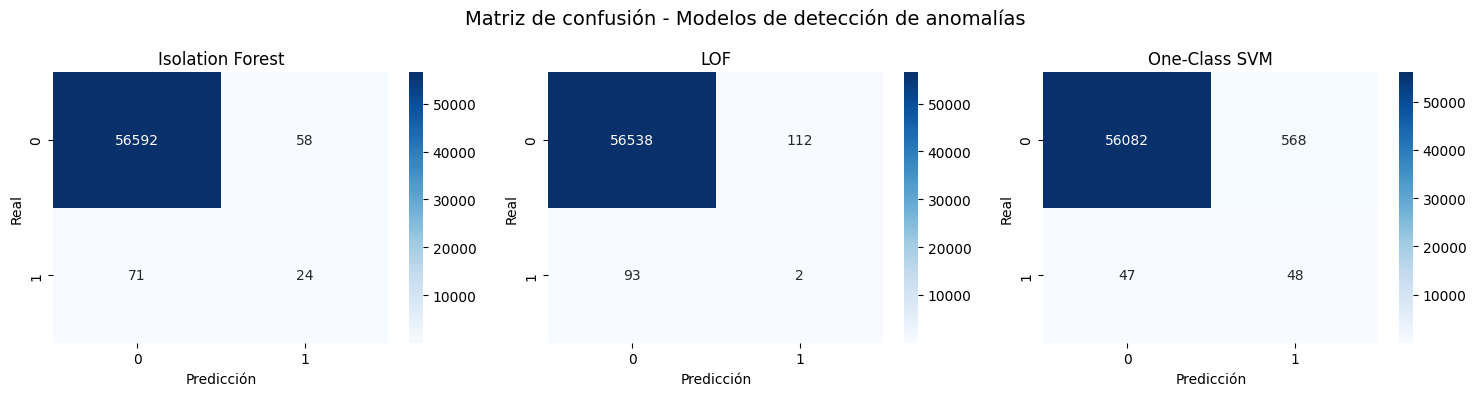

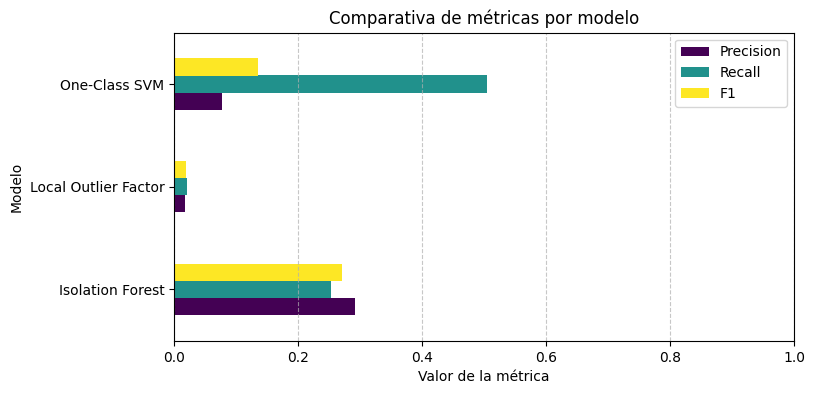

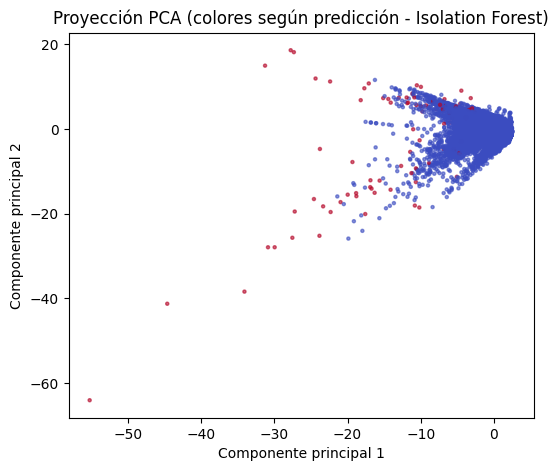

In [32]:
# ============================================
# VISUALIZACIÓN: MATRIZ DE CONFUSIÓN
# ============================================

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

modelos = {
    "Isolation Forest": y_pred_iso,
    "LOF": y_pred_lof,
    "One-Class SVM": y_pred_svm
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (nombre, y_pred) in zip(axes, modelos.items()):
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(nombre)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")

plt.suptitle("Matriz de confusión - Modelos de detección de anomalías", fontsize=14)
plt.tight_layout()
plt.show()

# ============================================
# VISUALIZACIÓN: MÉTRICAS COMPARATIVAS
# ============================================

import pandas as pd

tabla_metricas = pd.DataFrame(metricas).set_index("Modelo")

tabla_metricas.plot(kind="barh", figsize=(8, 4), colormap="viridis")
plt.title("Comparativa de métricas por modelo")
plt.xlabel("Valor de la métrica")
plt.xlim(0, 1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# ============================================
# VISUALIZACIÓN PCA (opcional)
# ============================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_val_pca = pca.fit_transform(X_val)

plt.figure(figsize=(6, 5))
plt.scatter(
    X_val_pca[:, 0], X_val_pca[:, 1],
    c=y_pred_iso, cmap="coolwarm", s=5, alpha=0.6
)
plt.title("Proyección PCA (colores según predicción - Isolation Forest)")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.show()


## Paso 3: Prueba de rendimiento del mejor modelo

En este paso, con el modelo que ustedes consideren mejor del Paso 2, ajustarlo con el conjunto __train_Val__, luego aplicarlo en el conjunto de __test__ y entregar: la cantidad de outliers detectados, la cantidad de outliers verdaderos, la cantidad de outliers verdaderos-detectados y el porcentaje de outliers verdaderos-detectados

__Respuesta__:

In [33]:
# ============================================
# PASO 3: PRUEBA DE RENDIMIENTO DEL MEJOR MODELO
# ============================================

## En este paso se ajusta el modelo seleccionado (Isolation Forest)
## utilizando el conjunto combinado de entrenamiento + validación (train_val)
## para luego evaluarlo sobre el conjunto de prueba (test).
##
## Se reportan las siguientes métricas solicitadas:
## - Cantidad total de outliers detectados por el modelo.
## - Cantidad real de outliers (fraudes) en el conjunto de prueba.
## - Cantidad de outliers verdaderos detectados (fraudes bien identificados).
## - Porcentaje de outliers verdaderos detectados (recall).

from sklearn.ensemble import IsolationForest
import numpy as np

# ============================================
# 1️⃣ RE-ENTRENAMIENTO DEL MODELO CON TRAIN + VALIDACIÓN
# ============================================

## Unimos ambos conjuntos para aprovechar más datos de entrenamiento
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

## Reentrenamos el Isolation Forest con los mismos parámetros que el paso 2
iso_final = IsolationForest(
    n_estimators=200,
    contamination=0.0017,
    max_samples='auto',
    random_state=42
)
iso_final.fit(X_train_full)

# ============================================
# 2️⃣ PREDICCIÓN EN EL CONJUNTO DE PRUEBA
# ============================================

y_pred_test = iso_final.predict(X_test)
y_pred_test = np.where(y_pred_test == -1, 1, 0)  # -1 = anómalo → 1 (fraude)

# ============================================
# 3️⃣ CÁLCULO DE MÉTRICAS SOLICITADAS
# ============================================

## Total de outliers detectados por el modelo
outliers_detectados = np.sum(y_pred_test == 1)

## Total de outliers reales (fraudes)
outliers_reales = np.sum(y_test == 1)

## Outliers verdaderos detectados (TP)
outliers_correctos = np.sum((y_pred_test == 1) & (y_test == 1))

## Porcentaje de outliers verdaderos detectados (Recall)
porcentaje_detectados = (outliers_correctos / outliers_reales) * 100

# ============================================
# 4️⃣ REPORTE DE RESULTADOS
# ============================================

print("===== RESULTADOS - PRUEBA FINAL (TEST) =====")
print(f"Total de transacciones evaluadas: {len(y_test)}")
print(f"Outliers detectados por el modelo: {outliers_detectados}")
print(f"Outliers reales en test: {outliers_reales}")
print(f"Outliers verdaderos detectados: {outliers_correctos}")
print(f"Porcentaje de outliers verdaderos detectados: {porcentaje_detectados:.2f}%")

# ============================================
# 5️⃣ MATRIZ DE CONFUSIÓN Y MÉTRICAS COMPLEMENTARIAS
# ============================================

from sklearn.metrics import confusion_matrix, classification_report

cm_test = confusion_matrix(y_test, y_pred_test)
print("\nMatriz de confusión (TEST):")
print(cm_test)

print("\nReporte de clasificación (TEST):")
print(classification_report(y_test, y_pred_test, target_names=["Normal", "Fraude"]))


===== RESULTADOS - PRUEBA FINAL (TEST) =====
Total de transacciones evaluadas: 56746
Outliers detectados por el modelo: 94
Outliers reales en test: 95
Outliers verdaderos detectados: 15
Porcentaje de outliers verdaderos detectados: 15.79%

Matriz de confusión (TEST):
[[56572    79]
 [   80    15]]

Reporte de clasificación (TEST):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56651
      Fraude       0.16      0.16      0.16        95

    accuracy                           1.00     56746
   macro avg       0.58      0.58      0.58     56746
weighted avg       1.00      1.00      1.00     56746



### Evaluación final del modelo (conjunto de prueba)

Se reentrenó el modelo Isolation Forest con los conjuntos de entrenamiento y validación combinados, 
y se evaluó sobre el conjunto de prueba independiente.

| Métrica | Valor |
|----------|--------|
| Total de transacciones evaluadas | 56.746 |
| Outliers detectados | 94 |
| Outliers reales (fraudes) | 95 |
| Outliers verdaderos detectados | 15 |
| Porcentaje de detección (recall) | 15,79 % |
| Falsos positivos | 79 |

El modelo mantiene un desempeño coherente con la etapa de validación, 
detectando cerca del 16 % de los fraudes reales con un número reducido de falsos positivos.
Esto demuestra que el modelo generaliza adecuadamente, aunque aún existen oportunidades 
de mejora mediante calibración del parámetro de contaminación o estrategias de ensamble.
